# MLP para Classificação de Sentimentos

Nesta etapa, os embeddings gerados pelo modelo `all-MiniLM-L6-v2` serão utilizados como características de entrada para uma rede neural **Multilayer Perceptron (MLP)**, implementada em `src/models/mlp_v1.py`.

## Objetivo

Classificar as avaliações de filmes em duas classes:

- `0` = negativo
- `1` = positivo

## Arquitetura da rede

| Camada | Neurônios | Ativação |
|---|---|---|
| Entrada | 384 (dimensão dos embeddings) | — |
| Oculta | definido no grid search (16, 32 ou 64) | Sigmoid |
| Saída | 1 | Sigmoid |

A saída é interpretada como a probabilidade de a avaliação ser positiva, com limiar de decisão de 0,5.

## Treinamento

- **Função de perda:** entropia cruzada binária
- **Otimização:** gradiente descendente (modo batch)
- **Cálculo dos gradientes:** backpropagation
- **Critério de parada:** parada antecipada (*early stopping*) com base na perda de validação

## Etapas

1. Carregamento dos embeddings.
2. Verificação dos dados.
3. Divisão dos dados em treinamento e teste (80/20).
4. Separação de 15% do treinamento para validação.
5. Busca de hiperparâmetros (grid search).
6. Avaliação do melhor modelo no teste.
7. Análise da matriz de confusão e da curva de aprendizado.
8. Salvamento das métricas e das figuras.

In [10]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.append(str(PROJECT_ROOT / "src"))

from models.mlp_v1 import MLP, carregar_dados

VERSAO = "mlp_v1"

In [11]:
df = pd.read_csv("../data/processed/IMDB_menor_embeddings.csv")
df.head()

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,sentiment
0,0.028352,0.058333,-0.069887,0.068288,0.080217,0.069166,0.040935,0.024101,0.073692,-0.060215,...,-0.078145,-0.024826,0.016664,0.013412,0.020879,0.065421,-0.025376,-0.050503,-0.025903,1
1,0.008254,0.065314,-0.004736,-0.051875,0.020606,0.084680,0.021552,0.006631,-0.015105,-0.015956,...,0.036724,0.038877,0.004208,-0.072306,0.010558,0.030873,0.010355,-0.050139,0.005361,1
2,0.014115,-0.076151,0.000104,0.013555,0.075392,0.070780,0.089844,0.067970,-0.018511,0.013720,...,-0.083469,-0.130850,0.057835,-0.062770,0.041212,0.055430,-0.030518,-0.000004,-0.083408,1
3,-0.051149,0.010064,-0.058461,-0.029111,0.056663,0.086137,0.018702,-0.010250,0.084562,-0.042020,...,-0.036892,0.000891,-0.016270,-0.003118,0.024032,0.069954,-0.015741,0.014551,0.015636,0
4,-0.040961,-0.015201,-0.030476,-0.034416,-0.023004,0.049733,0.055261,0.000040,0.111896,-0.046311,...,-0.009982,-0.027761,0.108200,-0.008198,-0.013424,0.011123,-0.027719,0.008909,0.026550,1


In [12]:
print(df.columns[-1])
print(df.iloc[:, -1].value_counts())

sentiment
sentiment
1    1005
0     995
Name: count, dtype: int64


In [13]:
X, y = carregar_dados(PROJECT_ROOT / "data" / "processed" / "IMDB_menor_embeddings.csv")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

print("Treino:   ", X_tr.shape)
print("Validação:", X_val.shape)
print("Teste:    ", X_test.shape)

Treino:    (1360, 384)
Validação: (240, 384)
Teste:     (400, 384)


In [14]:
grade = {
    "n_oculta": [16, 32, 64],
    "eta": [0.1, 0.5, 1.0],
}

resultados = []
modelos = {}

for n_oculta in grade["n_oculta"]:
    for eta in grade["eta"]:
        modelo = MLP(n_oculta=n_oculta, eta=eta).fit(X_tr, y_tr, X_val, y_val)
        f1_val = f1_score(y_val, modelo.predict(X_val), average="macro")

        modelos[(n_oculta, eta)] = modelo
        resultados.append({
            "param_n_oculta": n_oculta,
            "param_eta": eta,
            "melhor_epoca": modelo.melhor_epoca,
            "val_f1_macro": f1_val,
        })
        print(f"n_oculta={n_oculta:3d} | eta={eta:.1f} | melhor época={modelo.melhor_epoca:5d} | F1 validação={f1_val:.4f}")

gridsearch = pd.DataFrame(resultados).sort_values("val_f1_macro", ascending=False).reset_index(drop=True)
gridsearch

n_oculta= 16 | eta=0.1 | melhor época= 5416 | F1 validação=0.7785
n_oculta= 16 | eta=0.5 | melhor época= 1084 | F1 validação=0.7785
n_oculta= 16 | eta=1.0 | melhor época=  542 | F1 validação=0.7785
n_oculta= 32 | eta=0.1 | melhor época= 5662 | F1 validação=0.7826
n_oculta= 32 | eta=0.5 | melhor época= 1133 | F1 validação=0.7826
n_oculta= 32 | eta=1.0 | melhor época=  598 | F1 validação=0.7785
n_oculta= 64 | eta=0.1 | melhor época= 5471 | F1 validação=0.7828
n_oculta= 64 | eta=0.5 | melhor época= 1101 | F1 validação=0.7828
n_oculta= 64 | eta=1.0 | melhor época=  562 | F1 validação=0.7749


,param_n_oculta,param_eta,melhor_epoca,val_f1_macro
0,64,0.5,1101,0.782790
1,64,0.1,5471,0.782790
2,32,0.5,1133,0.782594
3,32,0.1,5662,0.782594
4,16,0.1,5416,0.778517
5,16,0.5,1084,0.778517
6,16,1.0,542,0.778517
7,32,1.0,598,0.778517
8,64,1.0,562,0.774937


In [15]:
melhor = gridsearch.iloc[0]
best_params = {"n_oculta": int(melhor["param_n_oculta"]), "eta": float(melhor["param_eta"])}
modelo = modelos[(best_params["n_oculta"], best_params["eta"])]
print("Melhores parâmetros:", best_params)

y_pred = modelo.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average="macro")

print(f"Acurácia teste: {test_accuracy:.4f} | F1 macro teste: {test_f1_macro:.4f}\n")
print(classification_report(y_test, y_pred, zero_division=0))

Melhores parâmetros: {'n_oculta': 64, 'eta': 0.5}
Acurácia teste: 0.8100 | F1 macro teste: 0.8100

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       199
           1       0.82      0.80      0.81       201

    accuracy                           0.81       400
   macro avg       0.81      0.81      0.81       400
weighted avg       0.81      0.81      0.81       400



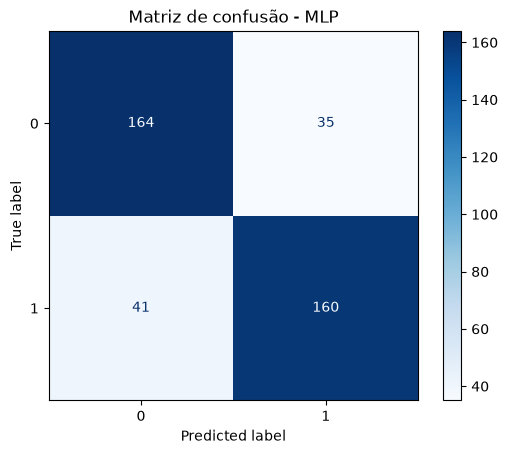

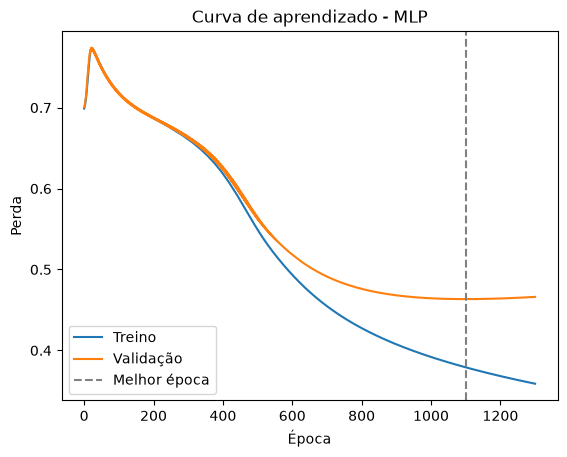

In [16]:
fig_cm, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=ax, cmap="Blues")
ax.set_title("Matriz de confusão - MLP")
plt.show()

fig_curva, ax = plt.subplots()
ax.plot(modelo.hist_treino, label="Treino")
ax.plot(modelo.hist_val, label="Validação")
ax.axvline(modelo.melhor_epoca, color="gray", linestyle="--", label="Melhor época")
ax.set_xlabel("Época")
ax.set_ylabel("Perda")
ax.set_title("Curva de aprendizado - MLP")
ax.legend()
plt.show()

In [17]:
METRICS_DIR = PROJECT_ROOT / "results" / "metrics" / "mlp"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures" / "mlp"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

resumo = {
    "best_params": best_params,
    "val_f1_macro": float(melhor["val_f1_macro"]),
    "test_f1_macro": float(test_f1_macro),
    "test_accuracy": float(test_accuracy),
}
with open(METRICS_DIR / f"{VERSAO}_resumo.json", "w") as f:
    json.dump(resumo, f, indent=2)

relatorio = classification_report(y_test, y_pred, zero_division=0, output_dict=True)
pd.DataFrame(relatorio).transpose().to_csv(METRICS_DIR / f"{VERSAO}_classification_report.csv")

gridsearch.to_csv(METRICS_DIR / f"{VERSAO}_gridsearch.csv", index=False)

fig_cm.savefig(FIGURES_DIR / f"{VERSAO}_matriz_confusao.png", dpi=150, bbox_inches="tight")
fig_curva.savefig(FIGURES_DIR / f"{VERSAO}_curva_aprendizado.png", dpi=150, bbox_inches="tight")

# Salvamento do modelo treinado (opcional)
# import joblib
# (PROJECT_ROOT / "models").mkdir(exist_ok=True)
# joblib.dump(modelo, PROJECT_ROOT / "models" / f"{VERSAO}.joblib")

print("Métricas salvas em:", METRICS_DIR)
print("Figuras salvas em:", FIGURES_DIR)

Métricas salvas em: /home/glauco/Programacao/VsCode/IA/Projeto-IA-classificacaoSentimentosFilme/results/metrics/mlp
Figuras salvas em: /home/glauco/Programacao/VsCode/IA/Projeto-IA-classificacaoSentimentosFilme/results/figures/mlp
